# Caminho para biblioteca

In [1]:
import sys
import os

# Get the absolute path of the current file's directory
current_dir = os.path.dirname(os.path.abspath('__file__'))

# Get the parent directory (which contains chemxai)
parent_dir = os.path.dirname(current_dir)

# Add the parent directory to sys.path
sys.path.append(parent_dir)

# Verify it was added
print(f"Added to sys.path: {parent_dir}")
print(sys.path)

Added to sys.path: /home/jonas/Documents/ToolBox-ChemXAI
['/usr/lib/python310.zip', '/usr/lib/python3.10', '/usr/lib/python3.10/lib-dynload', '', '/home/jonas/Documents/ToolBox-ChemXAI/Testing/venv/lib/python3.10/site-packages', '/home/jonas/Documents/ToolBox-ChemXAI']


# Usando MLP com dataset Iris

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import numpy as np

# Carregar o dataset Iris
iris = load_iris()
X = iris.data
y = iris.target

# Transformar em problema binário: classe 0 vs não-classe 0
y_bin = (y == 0).astype(int)

# Normalizar os dados
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Dividir em treino e teste
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_bin, test_size=0.2, random_state=42)

# Definir a MLP para binário
class MLP(nn.Module):
    def __init__(self, input_dim, hidden_dim=16):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1)
        )
    def forward(self, x):
        return self.net(x).squeeze(-1)

# Função de treino
def train_model(model, X_train, y_train, epochs=100):
    criterion = nn.BCEWithLogitsLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.01)
    X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
    y_train_tensor = torch.tensor(y_train, dtype=torch.float32)
    for epoch in range(epochs):
        optimizer.zero_grad()
        outputs = model(X_train_tensor)
        loss = criterion(outputs, y_train_tensor)
        loss.backward()
        optimizer.step()
    return model

# Treinar modelo original
mlp1 = MLP(input_dim=X_train.shape[1])
mlp1 = train_model(mlp1, X_train, y_train)

# Adicionar nova feature (valores aleatórios de 0 a 5)
np.random.seed(42)  # para reprodutibilidade
random_feature = np.random.uniform(0, 5, size=(X.shape[0], 1))
X_new = np.hstack([X, random_feature])
X_new_scaled = scaler.fit_transform(X_new)
X_train2, X_test2, y_train2, y_test2 = train_test_split(X_new_scaled, y_bin, test_size=0.2, random_state=42)

# Treinar modelo com nova feature
mlp2 = MLP(input_dim=X_train2.shape[1])
mlp2 = train_model(mlp2, X_train2, y_train2)

# Salvar os modelos
torch.save(mlp1.state_dict(), "mlp_iris_original_binario.pth")
torch.save(mlp2.state_dict(), "mlp_iris_novafeature_binario.pth")

# Avaliar erro no conjunto de teste para o modelo original
mlp1.eval()
with torch.no_grad():
    X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
    y_test_tensor = torch.tensor(y_test, dtype=torch.float32)
    outputs1 = mlp1(X_test_tensor)
    preds1 = (torch.sigmoid(outputs1) > 0.5).int()
    acc1 = (preds1 == y_test_tensor.int()).float().mean().item()
    print(f"Acurácia do modelo original (binário) no teste: {acc1:.4f}")

# Avaliar erro no conjunto de teste para o modelo com nova feature
mlp2.eval()
with torch.no_grad():
    X_test2_tensor = torch.tensor(X_test2, dtype=torch.float32)
    y_test2_tensor = torch.tensor(y_test2, dtype=torch.float32)
    outputs2 = mlp2(X_test2_tensor)
    preds2 = (torch.sigmoid(outputs2) > 0.5).int()
    acc2 = (preds2 == y_test2_tensor.int()).float().mean().item()
    print(f"Acurácia do modelo com nova feature (binário) no teste: {acc2:.4f}")

Acurácia do modelo original (binário) no teste: 1.0000
Acurácia do modelo com nova feature (binário) no teste: 1.0000


In [3]:
from torch.utils.data import TensorDataset, DataLoader

# Para o modelo original
train_dataset = TensorDataset(
    torch.tensor(X_train, dtype=torch.float32),
    torch.tensor(y_train, dtype=torch.long)
)
test_dataset = TensorDataset(
    torch.tensor(X_test, dtype=torch.float32),
    torch.tensor(y_test, dtype=torch.long)
)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

# Para o modelo com nova feature
train_dataset2 = TensorDataset(
    torch.tensor(X_train2, dtype=torch.float32),
    torch.tensor(y_train2, dtype=torch.long)
)
test_dataset2 = TensorDataset(
    torch.tensor(X_test2, dtype=torch.float32),
    torch.tensor(y_test2, dtype=torch.long)
)

train_loader2 = DataLoader(train_dataset2, batch_size=32, shuffle=True)
test_loader2 = DataLoader(test_dataset2, batch_size=32, shuffle=False)

In [4]:
from chemxai.explainers import Shap
from chemxai.explainers import Shap

exp_normal = Shap(model=mlp1, train_loader=train_loader, test_loader=test_loader, device='cpu')
exp_newfeatures = Shap(model=mlp2, train_loader=train_loader2, test_loader=test_loader2, device='cpu')



/home/jonas/Documents/ToolBox-ChemXAI/Testing/venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Background shape: (32, 4)
Test data shape: (30, 4)


100%|██████████| 30/30 [00:00<00:00, 490.68it/s]


Background shape: (32, 5)
Test data shape: (30, 5)


100%|██████████| 30/30 [00:00<00:00, 414.75it/s]


In [5]:
_, feature_importance_normal = exp_normal.global_explanation()

_, feature_importance_noise = exp_newfeatures.global_explanation()

Global SHAP values shape: (4,)
Global SHAP values shape: (5,)


In [6]:
feature_importance_normal

,Feature,Importance
0,3,1.973474
1,2,1.573631
2,1,1.557289
3,0,1.552873


In [7]:
feature_importance_noise

,Feature,Importance
0,3,2.369870
1,2,1.746864
2,1,1.487906
3,0,1.042675
4,4,0.132611


In [8]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.io as pio
import numpy as np
import pandas as pd

# Configurar para exibir no notebook, não no browser
pio.renderers.default = 'browser'

# Função para extrair labels e valores para os dados
def get_labels_and_values(df):
    # Se for um DataFrame pandas
    if isinstance(df, pd.DataFrame):
        # Verificar se temos coluna 'Feature' e 'Importance'
        if 'Feature' in df.columns and 'Importance' in df.columns:
            # Usar os valores da coluna Feature como labels
            labels = [str(f) for f in df['Feature'].values]
            values = df['Importance'].values
        else:
            # Usar o índice
            labels = df.index.astype(str).tolist()
            values = df.values.flatten()
    else:
        # Se for um dicionário
        if hasattr(df, 'keys'):
            labels = [str(k) for k in df.keys()]
            values = list(df.values())
        else:
            # Se for um array ou outro tipo
            labels = [str(i) for i in range(len(df))]
            values = df
            
    return labels, values

# Obter labels e valores
labels_normal, values_normal = get_labels_and_values(feature_importance_normal)
labels_noise, values_noise = get_labels_and_values(feature_importance_noise)

# Criar figura com subplots
fig = make_subplots(rows=1, cols=2, 
                   subplot_titles=("Modelo Original", "Modelo com Nova Feature"),
                   specs=[[{"type": "polar"}, {"type": "polar"}]])

# Fechar os polígonos
labels_normal_closed = labels_normal + [labels_normal[0]]
values_normal_closed = list(values_normal) + [values_normal[0]]

labels_noise_closed = labels_noise + [labels_noise[0]]
values_noise_closed = list(values_noise) + [values_noise[0]]

# Adicionar traços ao primeiro gráfico (modelo original)
fig.add_trace(
    go.Scatterpolar(
        r=values_normal_closed,
        theta=labels_normal_closed,
        fill='toself',
        name='Original',
        line=dict(color='blue'),
        marker=dict(size=10)
    ),
    row=1, col=1
)

# Adicionar traços ao segundo gráfico (modelo com nova feature)
fig.add_trace(
    go.Scatterpolar(
        r=values_noise_closed,
        theta=labels_noise_closed,
        fill='toself',
        name='Nova Feature',
        line=dict(color='red'),
        marker=dict(size=10)
    ),
    row=1, col=2
)

# Configurar layout para exibir como polígonos
fig.update_layout(
    title="Importância das Features por Modelo",
    height=500,
    width=1000,
    showlegend=True,
    polar=dict(
        radialaxis=dict(visible=True, range=[0, max(max(values_normal), max(values_noise)) * 1.1]),
        angularaxis=dict(
            visible=True,
            categoryarray=labels_normal,
            categoryorder='array'
        )
    ),
    polar2=dict(
        radialaxis=dict(visible=True, range=[0, max(max(values_normal), max(values_noise)) * 1.1]),
        angularaxis=dict(
            visible=True,
            categoryarray=labels_noise,
            categoryorder='array'
        )
    )
)

fig.show()

# Usando MLP com QM9

In [9]:
from chemxai.data import qm9_tubular
from chemxai.models import MLP
from chemxai.explainers import Shap

In [10]:
data = qm9_tubular()
train_loader, _, test_loader, X = data.get_dataloader()
model = MLP(input_dim=X.shape[1], output_dim=1, layers=[180], device='cpu',lr=0.001)
print(model)
shap_explainer = Shap(model=model, train_loader=train_loader, test_loader=test_loader, device='cpu')
global_exp = shap_explainer.global_explanation()
print(global_exp)

Dados salvos em: /home/jonas/Documents/ToolBox-ChemXAI/Testing/data/QM9_tubular_Data
MLP(
  (layers): Sequential(
    (0): Linear(in_features=8, out_features=180, bias=True)
    (1): ReLU()
    (2): Linear(in_features=180, out_features=1, bias=True)
  )
  (criterion): L1Loss()
)
Background shape: (8, 8)
Test data shape: (1, 8)


100%|██████████| 1/1 [00:00<00:00, 42.39it/s]


IndexError: tuple index out of range

# GCN e QM9 com GraphShap

In [ ]:
from chemxai.data import prepare_data_graph
from chemxai.models import GCN
from chemxai.explainers import GraphShap
from chemxai.plots import radar_plot

In [39]:
# Teste GCN com QM9 e GraphShap -> Funcional -> Explicação para as features do grafo 0
data = prepare_data_graph('QM9')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = GCN(num_features=data.num_features).to(device)
model.load_state_dict(torch.load('models/gcn_qm9.pth', map_location=torch.device(device)))
model = model.to(device)
explainer = GraphShap(data[0], model, device, gpu=torch.cuda.is_available())
explanation = explainer.explain()
print("Shapley Values for Node Features:")
print(explanation['shap_values'])
print("\nTop Features (if applicable):")
print(explanation['top_features'])
print("\nTop Shapley Values (if applicable):")
print(explanation['top_values'])

/home/jonas/Documents/ToolBox-ChemXAI/Testing/data/QM9
Shapley Values for Node Features:
[ 0.69184317  0.25782427  0.13579592  0.42220793  0.88130606 -8.32538758
 -0.21651963  0.03705736  0.15213637  0.30691575 -2.50784269]

Top Features (if applicable):
[ 5 10  4  0  3  9  1  6  8  2  7]

Top Shapley Values (if applicable):
[-8.32538758 -2.50784269  0.88130606  0.69184317  0.42220793  0.30691575
  0.25782427 -0.21651963  0.15213637  0.13579592  0.03705736]


/tmp/ipykernel_8357/2014674004.py:62: UserWarning:

Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.



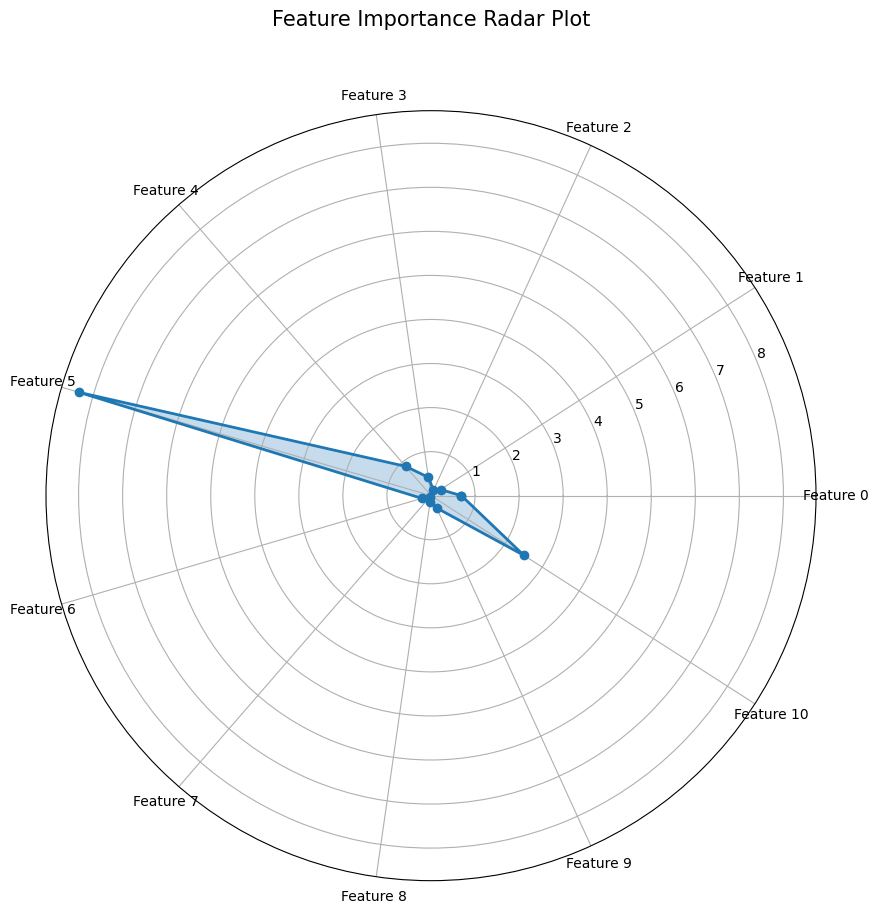

In [ ]:
# Example usage with your data
# Assuming 'explanation' contains your SHAP explanation
feature_names = explanation.get('feature_names', None)  # Replace with your actual feature names if available
shap_values = explanation['shap_values']

fig, ax = radar_plot(shap_values, feature_names)

fig.show()

## Avaliações

Teste 1: [ 5 10  1  4  3  0  2  7  8  6  9]\
Teste 2: [ 5 10  1  9  7  2  3  4  0  6  8]\
Teste 3: [ 5 10  1  6  7  8  4  0  2  9  3]\
Teste 4: [ 5 10  1  9  6  7  8  0  4  2  3]\
Teste 5: [ 5 10  2  8  9  7  0  1  4  3  6]\
Teste 6: [ 5 10  0  6  1  2  9  7  4  8  3]\
Teste 7: [ 5 10  9  8  1  4  2  7  3  6  0]\
Teste 8: [ 5 10  4  0  3  9  1  6  8  2  7]


# GCN e QM9 com GraphLIME

In [52]:
from chemxai.explainers import GraphLIME

In [61]:
data = prepare_data_graph('QM9')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = GCN(num_features=data.num_features).to(device)
model.load_state_dict(torch.load('models/gcn_qm9.pth', map_location=torch.device(device)))
model = model.to(device)
explainer = GraphLIME(model=model, device=device, rho=0.1)
explanation = explainer.explain(data[0], num_samples=100)
print("Features Importance:")
print(explanation['feature_importance'])
print("\nTop Features:")
print(explanation['top_features'])

/home/jonas/Documents/ToolBox-ChemXAI/Testing/data/QM9
Features Importance:
[0.05408281 0.03167737 0.         0.04684616 0.1051273  0.
 0.04371131 0.03835984 0.2034954  0.0359005  0.08578927]

Top Features:
[ 8  4 10  0  3  6  7  9  1  5  2]


/tmp/ipykernel_8357/3967352543.py:8: UserWarning:

Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.



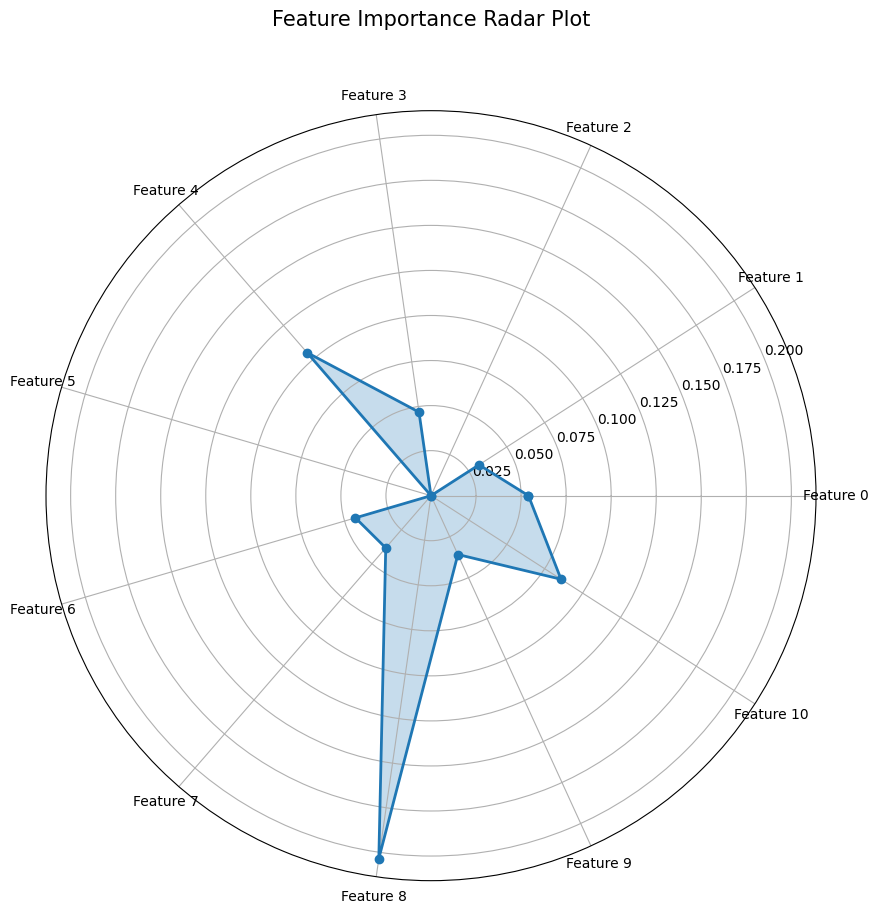

In [62]:
# Example usage with your data
# Assuming 'explanation' contains your SHAP explanation
feature_names = explanation.get('feature_names', None)  # Replace with your actual feature names if available
lime_values = explanation['feature_importance']

fig, ax = radar_plot(lime_values, feature_names)

fig.show()